# Extract node community for a given local order data
1. Load data
2. Extract node community
3. Plot global,local synchrony and node community
4. Verify that node community data is collected for transition

- Results: Verified that node community is collected for every transitions

In [1]:
%reload_ext autoreload
%autoreload 2

from tes.analysis import AnalysisFunc
from tes.data_ingestion import DataRead

import matplotlib.pyplot as plt
import numpy as np

In [2]:
reader = DataRead()
analyse = AnalysisFunc()

In [3]:
# df_loc = reader.data_read_bz2("raw/test/loc_test.bz2")
# df_itr = reader.data_read_bz2("raw/test/itr_test.bz2")
df_loc = reader.data_read_bz2("raw/PERI/loc_200.bz2")
df_itr = reader.data_read_bz2("raw/PERI/itr_200.bz2")

In [4]:
params = analyse.compute_param(df_itr, 0.05)

Number of transitions / 100 iteration [0, 36, 76]
Number of transition [3, 5, 6, 8, 9, 12, 16, 18, 20, 25, 37, 43, 46, 47, 48, 52, 54, 55, 57, 59, 60, 62, 73, 75, 78, 79, 89, 90, 91, 93, 98, 100, 102, 108, 113, 114, 116, 118, 122, 124, 125, 127, 131, 132, 133, 138, 139, 141, 142, 148, 153, 156, 158, 159, 160, 169, 172, 176, 178, 181, 182, 183, 185, 186, 195]
Number of transition with more than one transition or a fall back [16, 43, 54, 62, 79, 98, 113, 116, 122, 125, 141, 153, 169, 172, 176, 182, 186]


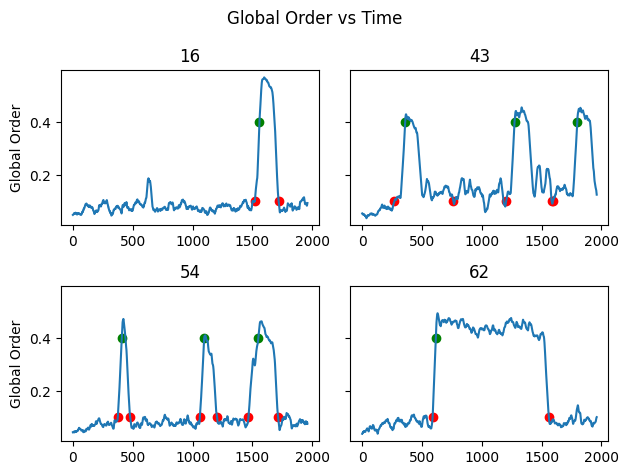

In [7]:
# plot iteration 2,4,5 and 7
fig, ax = plt.subplots(2, 2, sharey=True)

n = 16
df_smooth = analyse.smooth(df_itr[n])
l = analyse.trans_state_time(analyse.smooth(df_itr[n]), 0.05)
ax[0, 0].plot(l["low_cros"], [0.1] * len(l["low_cros"]), "ro")
ax[0, 0].plot(l["up_cros"], [0.4] * len(l["up_cros"]), "go")
time = analyse.get_time(df_itr[n], 0.05)
ax[0, 0].plot(time, df_smooth)
ax[0, 0].set_title(str(n))
ax[0, 0].set_ylabel("Global Order")

n = 43
df_smooth = analyse.smooth(df_itr[n])
l = analyse.trans_state_time(analyse.smooth(df_itr[n]), 0.05)
ax[0, 1].plot(l["low_cros"], [0.1] * len(l["low_cros"]), "ro")
ax[0, 1].plot(l["up_cros"], [0.4] * len(l["up_cros"]), "go")
time = analyse.get_time(df_itr[n], 0.05)
ax[0, 1].plot(time, df_smooth)
ax[0, 1].set_title(str(n))

n = 54
df_smooth = analyse.smooth(df_itr[n])
l = analyse.trans_state_time(analyse.smooth(df_itr[n]), 0.05)
ax[1, 0].plot(l["low_cros"], [0.1] * len(l["low_cros"]), "ro")
ax[1, 0].plot(l["up_cros"], [0.4] * len(l["up_cros"]), "go")
time = analyse.get_time(df_itr[n], 0.05)
ax[1, 0].plot(time, df_smooth)
ax[1, 0].set_title(str(n))
ax[1, 0].set_ylabel("Global Order")

n = 62
df_smooth = analyse.smooth(df_itr[n])
l = analyse.trans_state_time(analyse.smooth(df_itr[n]), 0.05)
ax[1, 1].plot(l["low_cros"], [0.1] * len(l["low_cros"]), "ro")
ax[1, 1].plot(l["up_cros"], [0.4] * len(l["up_cros"]), "go")
time = analyse.get_time(df_itr[n], 0.05)
ax[1, 1].plot(time, df_smooth)
ax[1, 1].set_title(str(n))

fig.suptitle("Global Order vs Time")
fig.tight_layout()

Above validates that node extraction function, extracts node community data for each transition

In [9]:
# df_nc = reader.data_read_bz2("nc_test.bz2")
df_nc = reader.data_read_bz2("raw/PERI/nc_200.bz2")

In [10]:
# checking indices of df_nc
df_reset = df_nc.reset_index()
df_reset["level_0"].drop_duplicates()

0           3
5000        5
10000       6
15000       8
20000       9
         ... 
350000    182
355000    183
360000    185
365000    186
375000    195
Name: level_0, Length: 65, dtype: int64

Node community data validates node community data is captured for every transition

#### Plot global order, local order and node community data for every transition in iteration 7

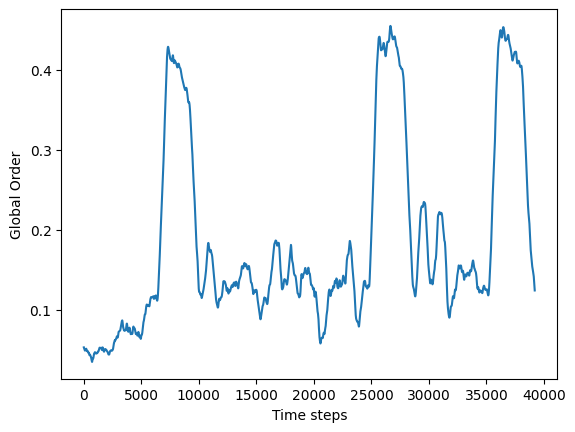

In [11]:
analyse.plot_global_synchrony(df_itr[43], 0.05)

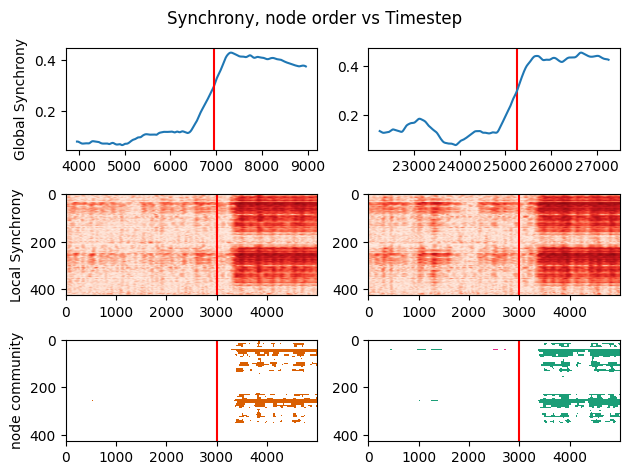

In [12]:
n = 43
smooth = np.array(analyse.smooth(df_itr[n]))

fig, ax = plt.subplots(3, 2)

# plot 1st transition
cross = np.where(smooth > 0.3)[0][0]
ax[0, 0].plot(
    list(range(cross - 3000, cross + 2000)), smooth[cross - 3000 : cross + 2000]
)
ax[0, 0].axvline(cross, color="r")
ax[0, 0].set_ylabel("Global Synchrony")

ax[1, 0].imshow(df_loc.loc[n].iloc[0:426].values, cmap="Reds", aspect="auto")
ax[1, 0].set_ylabel("Local Synchrony")
ax[1, 0].axvline(3000, color="r")

nc_array = df_nc.loc[n].iloc[0:5000].values
mc = analyse.compute_main_cluster(df_nc.loc[n].iloc[0:5000])
nc_array[nc_array == 0] = np.nan
ax[2, 0].imshow(nc_array.T, cmap="Dark2", aspect="auto")
ax[2, 0].axvline(3000, color="r")
ax[2, 0].set_ylabel("node community")

# plot 2nd transition
data_indices = np.arange(len(smooth))
uc = np.where(smooth >= 0.4)[0][0]
data = np.array(smooth[uc:])
data_indices = data_indices[uc:]
ind = np.where(data <= 0.1)[0][0]
data = data[ind:]
data_indices = data_indices[ind:]
cross2 = np.where(data > 0.3)[0][0]
cross2_up = cross2 + data_indices[0]
ax[0, 1].axvline(cross2_up, color="r")
ax[0, 1].plot(
    list(range(cross2_up - 3000, cross2_up + 2000)), data[cross2 - 3000 : cross2 + 2000]
)

# ax[0,1].set_ylabel('Global Synchrony')

ax[1, 1].imshow(df_loc.loc[n].iloc[426:852].values, cmap="Reds", aspect="auto")
# ax[1,1].set_ylabel('Local Synchrony')
ax[1, 1].axvline(3000, color="r")

nc_array = df_nc.loc[n].iloc[5000:10000].values
mc = analyse.compute_main_cluster(df_nc.loc[n].iloc[5000:10000])
nc_array[nc_array == 0] = np.nan
ax[2, 1].imshow(nc_array.T, cmap="Dark2", aspect="auto")
ax[2, 1].axvline(3000, color="r")


fig.suptitle("Synchrony, node order vs Timestep")
fig.tight_layout()

Verifies that all three data is collected for a particular transition